In [1]:
import pandas as pd
import sqlite3
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')

# Прогноз удовлетворённости клиента для маркетплейса Olist

**Автор:** Данияр Баекеев<br>
**Дата:** Сентябрь 2026<br>
**Датасет:** [Brazilian E-Commerce Public Dataset by Olist](https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce)


---

## Введение

### Контекст
Olist — бразильский маркетплейс, объединяющий множество продавцов на одной платформе. Датасет содержит реальные анонимизированные данные о заказах, товарах, продавцах, оплатах, доставке и отзывах клиентов.

### Проблема
Низкая оценка клиента — это не только негативный отзыв, но и сигнал о проблемах с логистикой, стоимостью доставки, товаром или продавцом. Обычно бизнес узнаёт об этом уже после публикации отзыва.

### Вопрос
Можно ли предсказать, что клиент поставит низкую оценку (1–2 звезды), используя только данные, которые уже известны к моменту доставки заказа?

### Цель
Построить модель бинарной классификации, которая оценивает риск низкой оценки и позволяет заранее выделять заказы, требующие внимания клиентского сервиса.


---

### 1. Подготовка и очистка датасета

In [2]:
customers = pd.read_csv('datasets/olist_customers_dataset.csv')
geolocation = pd.read_csv('datasets/olist_geolocation_dataset.csv')
order_items = pd.read_csv('datasets/olist_order_items_dataset.csv')
order_payments = pd.read_csv('datasets/olist_order_payments_dataset.csv')
order_reviews = pd.read_csv('datasets/olist_order_reviews_dataset.csv')
orders = pd.read_csv('datasets/olist_orders_dataset.csv')
products = pd.read_csv('datasets/olist_products_dataset.csv')
sellers = pd.read_csv('datasets/olist_sellers_dataset.csv')
category_translation = pd.read_csv('datasets/product_category_name_translation.csv')

tables = {
    'customers': customers,
    'geolocation': geolocation,
    'order_items': order_items,
    'order_payments': order_payments,
    'order_reviews': order_reviews,
    'orders': orders,
    'products': products,
    'sellers': sellers,
    'category_translation': category_translation
}

In [3]:
# Быстрая диагностика пропусков по всем таблицам
diagnostics = []

for table_name, df in tables.items():
    for col in df.columns:
        diagnostics.append({
            'Таблица': table_name,
            'Признак': col,
            'Тип данных': str(df[col].dtype),
            'Пропуски': int(df[col].isna().sum()),
            'Пропуски (%)': round(df[col].isna().mean() * 100, 2),
            'Уникальных значений': int(df[col].nunique(dropna=False))
        })

report_df = pd.DataFrame(diagnostics)

print('Топ-20 признаков по доле пропусков:')
display(
    report_df
    .sort_values('Пропуски (%)', ascending=False)
    .head(20)
    .reset_index(drop=True)
)

Топ-20 признаков по доле пропусков:


,Таблица,Признак,Тип данных,Пропуски,Пропуски (%),Уникальных значений
0,order_reviews,review_comment_title,str,87656,88.34,4528
1,order_reviews,review_comment_message,str,58247,58.70,36160
2,orders,order_delivered_customer_date,str,2965,2.98,95665
3,products,product_name_lenght,float64,610,1.85,67
4,products,product_photos_qty,float64,610,1.85,20
5,products,product_category_name,str,610,1.85,74
6,products,product_description_lenght,float64,610,1.85,2961
7,orders,order_delivered_carrier_date,str,1783,1.79,81019
8,orders,order_approved_at,str,160,0.16,90734
9,products,product_weight_g,float64,2,0.01,2205


### 2. Построение реляционной БД (SQLite) и SQL-агрегации

In [4]:
# Создаём SQLite-базу и загружаем в неё все 9 таблиц
DB_PATH = 'olist_capstone.db'
conn = sqlite3.connect(DB_PATH)

sql_table_names = {
    'customers': 'customers',
    'geolocation': 'geolocation',
    'order_items': 'order_items',
    'order_payments': 'order_payments',
    'order_reviews': 'order_reviews',
    'orders': 'orders',
    'products': 'products',
    'sellers': 'sellers',
    'category_translation': 'category_translation',
}

for key, sql_name in sql_table_names.items():
    tables[key].to_sql(sql_name, conn, if_exists='replace', index=False)

# Индексируем
index_queries = [
    'CREATE INDEX IF NOT EXISTS idx_orders_order_id ON orders(order_id);',
    'CREATE INDEX IF NOT EXISTS idx_orders_customer_id ON orders(customer_id);',
    'CREATE INDEX IF NOT EXISTS idx_customers_customer_id ON customers(customer_id);',
    'CREATE INDEX IF NOT EXISTS idx_items_order_id ON order_items(order_id);',
    'CREATE INDEX IF NOT EXISTS idx_items_product_id ON order_items(product_id);',
    'CREATE INDEX IF NOT EXISTS idx_items_seller_id ON order_items(seller_id);',
    'CREATE INDEX IF NOT EXISTS idx_payments_order_id ON order_payments(order_id);',
    'CREATE INDEX IF NOT EXISTS idx_reviews_order_id ON order_reviews(order_id);',
    'CREATE INDEX IF NOT EXISTS idx_products_product_id ON products(product_id);',
    'CREATE INDEX IF NOT EXISTS idx_sellers_seller_id ON sellers(seller_id);',
]

for query in index_queries:
    conn.execute(query)

conn.commit()

In [5]:
# Схема связей между таблицами
relationships = pd.DataFrame([
    ['orders', 'customer_id', 'customers', 'customer_id', 'многие заказы -> один customer_id'],
    ['order_items', 'order_id', 'orders', 'order_id', 'много позиций -> один заказ'],
    ['order_items', 'product_id', 'products', 'product_id', 'позиция -> товар'],
    ['order_items', 'seller_id', 'sellers', 'seller_id', 'позиция -> продавец'],
    ['order_payments', 'order_id', 'orders', 'order_id', 'много платежей -> один заказ'],
    ['order_reviews', 'order_id', 'orders', 'order_id', 'отзыв -> заказ'],
    ['products', 'product_category_name', 'category_translation', 'product_category_name', 'перевод категории'],
    ['customers', 'customer_zip_code_prefix', 'geolocation', 'geolocation_zip_code_prefix', 'география, опционально'],
    ['sellers', 'seller_zip_code_prefix', 'geolocation', 'geolocation_zip_code_prefix', 'география, опционально'],
], columns=['Таблица A', 'Ключ A', 'Таблица B', 'Ключ B', 'Связь'])

In [6]:
# Формируем признаки на уровне одного заказа

sql_query = '''
WITH item_agg AS (
    SELECT
        oi.order_id,
        COUNT(*) AS item_count,
        COUNT(DISTINCT oi.product_id) AS product_count,
        COUNT(DISTINCT oi.seller_id) AS seller_count,
        SUM(oi.price) AS total_price,
        SUM(oi.freight_value) AS total_freight,
        AVG(oi.price) AS avg_item_price,
        AVG(p.product_weight_g) AS avg_product_weight_g,
        AVG(
            CASE
                WHEN p.product_length_cm IS NOT NULL
                 AND p.product_height_cm IS NOT NULL
                 AND p.product_width_cm IS NOT NULL
                THEN p.product_length_cm * p.product_height_cm * p.product_width_cm
            END
        ) AS avg_product_volume_cm3
    FROM order_items oi
    LEFT JOIN products p
        ON oi.product_id = p.product_id
    GROUP BY oi.order_id
),

first_item AS (
    SELECT
        oi.order_id,
        COALESCE(t.product_category_name_english, p.product_category_name, 'unknown') AS primary_category,
        s.seller_state AS primary_seller_state,
        s.seller_city AS primary_seller_city
    FROM order_items oi
    LEFT JOIN products p
        ON oi.product_id = p.product_id
    LEFT JOIN category_translation t
        ON p.product_category_name = t.product_category_name
    LEFT JOIN sellers s
        ON oi.seller_id = s.seller_id
    WHERE oi.order_item_id = 1
),

payment_agg AS (
    SELECT
        order_id,
        SUM(payment_value) AS total_payment_value,
        MAX(payment_installments) AS max_payment_installments,
        COUNT(*) AS payment_records,
        MAX(CASE WHEN payment_type = 'credit_card' THEN 1 ELSE 0 END) AS pay_credit_card,
        MAX(CASE WHEN payment_type = 'boleto' THEN 1 ELSE 0 END) AS pay_boleto,
        MAX(CASE WHEN payment_type = 'voucher' THEN 1 ELSE 0 END) AS pay_voucher,
        MAX(CASE WHEN payment_type = 'debit_card' THEN 1 ELSE 0 END) AS pay_debit_card
    FROM order_payments
    GROUP BY order_id
),

review_ranked AS (
    SELECT
        order_id,
        review_score,
        review_creation_date,
        review_answer_timestamp,
        ROW_NUMBER() OVER (
            PARTITION BY order_id
            ORDER BY review_answer_timestamp DESC, review_creation_date DESC
        ) AS rn
    FROM order_reviews
),

review_one AS (
    SELECT order_id, review_score
    FROM review_ranked
    WHERE rn = 1
)

SELECT
    o.order_id,
    o.order_status,
    o.order_purchase_timestamp,
    o.order_approved_at,
    o.order_delivered_carrier_date,
    o.order_delivered_customer_date,
    o.order_estimated_delivery_date,

    c.customer_state,
    c.customer_city,

    ia.item_count,
    ia.product_count,
    ia.seller_count,
    ia.total_price,
    ia.total_freight,
    ia.avg_item_price,
    ia.avg_product_weight_g,
    ia.avg_product_volume_cm3,

    fi.primary_category,
    fi.primary_seller_state,
    fi.primary_seller_city,

    pa.total_payment_value,
    pa.max_payment_installments,
    pa.payment_records,
    pa.pay_credit_card,
    pa.pay_boleto,
    pa.pay_voucher,
    pa.pay_debit_card,

    CAST(
        julianday(o.order_delivered_customer_date) - julianday(o.order_purchase_timestamp)
        AS REAL
    ) AS delivery_time_days,

    CAST(
        julianday(o.order_delivered_customer_date) - julianday(o.order_estimated_delivery_date)
        AS REAL
    ) AS delivery_delay_days,

    CAST(
        julianday(o.order_estimated_delivery_date) - julianday(o.order_purchase_timestamp)
        AS REAL
    ) AS promised_delivery_days,

    CAST(
        (julianday(o.order_approved_at) - julianday(o.order_purchase_timestamp)) * 24
        AS REAL
    ) AS approval_time_hours,

    CAST(
        julianday(o.order_delivered_customer_date) - julianday(o.order_delivered_carrier_date)
        AS REAL
    ) AS carrier_to_customer_days,

    CASE
        WHEN o.order_delivered_customer_date > o.order_estimated_delivery_date THEN 1
        ELSE 0
    END AS is_late,

    CAST(strftime('%w', o.order_purchase_timestamp) AS INTEGER) AS purchase_weekday,
    CAST(strftime('%H', o.order_purchase_timestamp) AS INTEGER) AS purchase_hour,

    r.review_score

FROM orders o
JOIN customers c
    ON o.customer_id = c.customer_id
JOIN item_agg ia
    ON o.order_id = ia.order_id
LEFT JOIN first_item fi
    ON o.order_id = fi.order_id
LEFT JOIN payment_agg pa
    ON o.order_id = pa.order_id
JOIN review_one r
    ON o.order_id = r.order_id

WHERE o.order_status = 'delivered'
  AND o.order_delivered_customer_date IS NOT NULL
  AND o.order_estimated_delivery_date IS NOT NULL;
'''

df_final = pd.read_sql_query(sql_query, conn)

print(f'Итоговая таблица на уровне заказа: {df_final.shape[0]:,} строк, {df_final.shape[1]} столбцов')

Итоговая таблица на уровне заказа: 95,824 строк, 36 столбцов


In [7]:
# Проверяем главный принцип: одна строка = один заказ
duplicate_orders = df_final['order_id'].duplicated().sum()

print(f'Дубликатов order_id: {duplicate_orders}')
assert duplicate_orders == 0, 'После SQL-сборки появились дубликаты заказов.'

final_missing = (
    df_final.isna().mean()
    .mul(100)
    .sort_values(ascending=False)
    .rename('Пропуски (%)')
    .to_frame()
)

display(final_missing.head(15))

Дубликатов order_id: 0


,Пропуски (%)
avg_product_weight_g,0.016697
avg_product_volume_cm3,0.016697
order_approved_at,0.014610
approval_time_hours,0.014610
pay_credit_card,0.001044
pay_debit_card,0.001044
pay_voucher,0.001044
order_delivered_carrier_date,0.001044
max_payment_installments,0.001044
payment_records,0.001044


### 3. Разведочный анализ данных (EDA)

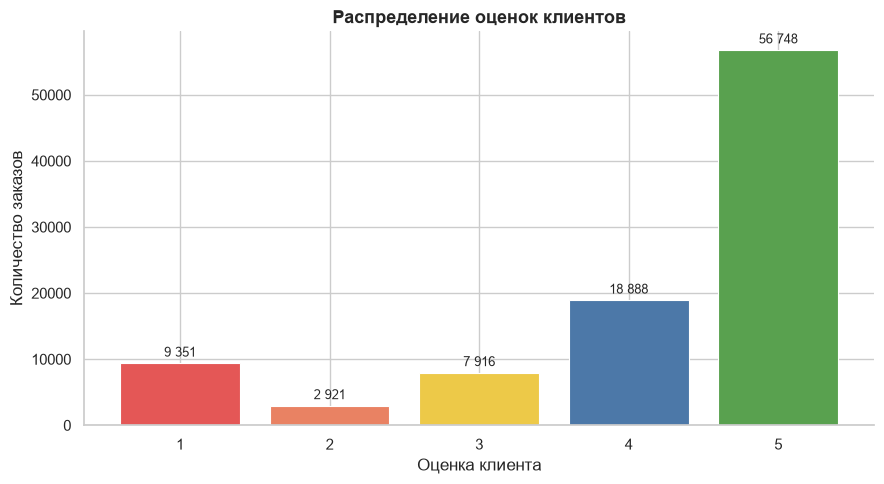

In [8]:
# Цвета для графиков EDA
BLUE = '#4C78A8'
RED = '#E45756'
GREEN = '#59A14F'
ORANGE = '#F28E2B'
YELLOW = '#EDC948'

# Распределение оценок 1-5
review_distribution = (
    df_final['review_score']
    .value_counts()
    .sort_index()
    .rename_axis('review_score')
    .reset_index(name='orders')
)

rating_colors = [RED, '#E98263', YELLOW, BLUE, GREEN]

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(
    review_distribution['review_score'].astype(str),
    review_distribution['orders'],
    color=rating_colors,
    edgecolor='white',
    linewidth=0.8
)

ax.set_title('Распределение оценок клиентов', fontsize=13, fontweight='bold')
ax.set_xlabel('Оценка клиента')
ax.set_ylabel('Количество заказов')

for bar in bars:
    height = bar.get_height()
    ax.annotate(
        f'{int(height):,}'.replace(',', ' '),
        (bar.get_x() + bar.get_width() / 2, height),
        ha='center',
        va='bottom',
        fontsize=9,
        xytext=(0, 3),
        textcoords='offset points'
    )

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

**Вывод:**

Низкие оценки 1–2 звезды составляют 12.8% заказов. Поэтому задача является несбалансированной, и обычной Accuracy для оценки модели будет недостаточно.

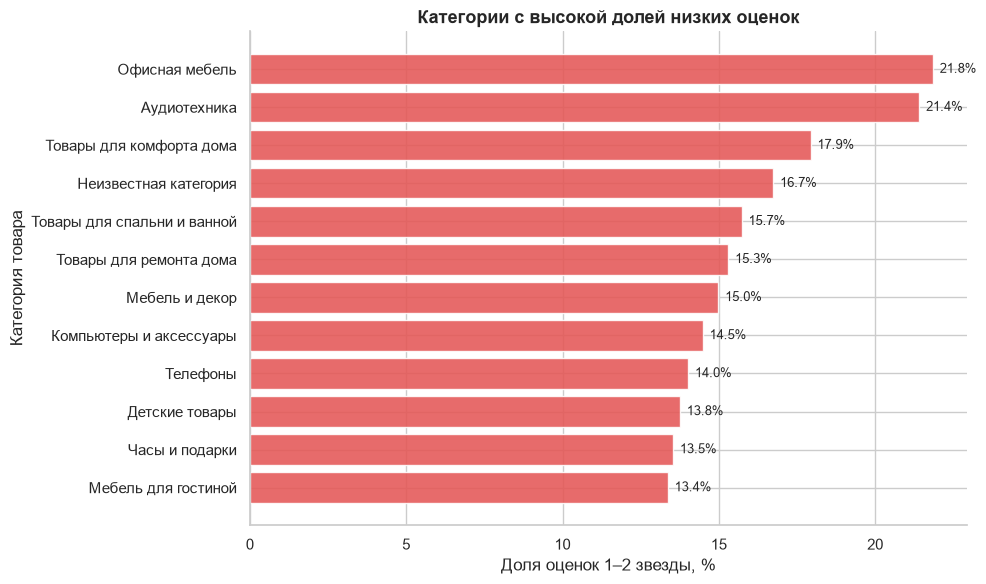

In [9]:
# Категории товаров: берём только достаточно частые категории,
# чтобы не делать выводы по нескольким отдельным заказам.
category_stat = (
    df_final
    .groupby('primary_category')
    .agg(
        orders=('order_id', 'count'),
        low_rating_rate=('review_score', lambda x: (x <= 2).mean() * 100)
    )
    .reset_index()
)

category_stat = category_stat[category_stat['orders'] >= 300]
category_stat = category_stat.sort_values('low_rating_rate', ascending=False).head(12)

# Перевод категорий, которые попадают в итоговый Top-12
category_translation_ru = {
    'office_furniture': 'Офисная мебель',
    'audio': 'Аудиотехника',
    'home_confort': 'Товары для комфорта дома',
    'unknown': 'Неизвестная категория',
    'bed_bath_table': 'Товары для спальни и ванной',
    'home_construction': 'Товары для ремонта дома',
    'furniture_decor': 'Мебель и декор',
    'computers_accessories': 'Компьютеры и аксессуары',
    'telephony': 'Телефоны',
    'baby': 'Детские товары',
    'watches_gifts': 'Часы и подарки',
    'furniture_living_room': 'Мебель для гостиной'
}

category_stat['category_ru'] = (
    category_stat['primary_category']
    .map(category_translation_ru)
    .fillna(category_stat['primary_category'])
)

plot_cat = category_stat.sort_values('low_rating_rate')

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(
    plot_cat['category_ru'],
    plot_cat['low_rating_rate'],
    color=RED,
    alpha=0.88
)

ax.set_title(
    'Категории с высокой долей низких оценок',
    fontsize=13,
    fontweight='bold'
)
ax.set_xlabel('Доля оценок 1–2 звезды, %')
ax.set_ylabel('Категория товара')

for bar in bars:
    width = bar.get_width()
    ax.annotate(
        f'{width:.1f}%',
        (width, bar.get_y() + bar.get_height() / 2),
        ha='left',
        va='center',
        fontsize=9,
        xytext=(5, 0),
        textcoords='offset points'
    )

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()


**Вывод:**

Риск низкой оценки зависит не только от логистики. Между товарными категориями также есть различия, поэтому категорию товара имеет смысл сохранить среди признаков.

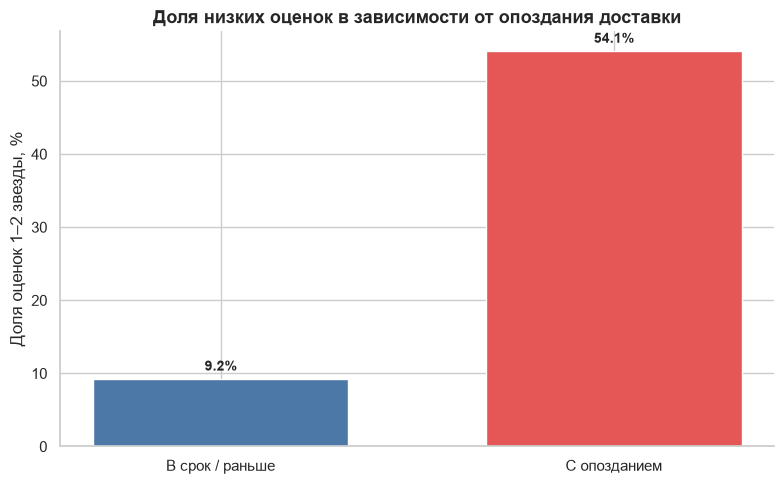

In [10]:
# Связь опоздания доставки и низкой оценки
eda_delivery = df_final.copy()

eda_delivery['Низкая оценка'] = np.where(
    eda_delivery['review_score'] <= 2,
    '1–2 звезды',
    '3–5 звёзд'
)

eda_delivery['Статус доставки'] = np.where(
    eda_delivery['is_late'] == 1,
    'С опозданием',
    'В срок / раньше'
)

late_stat = (
    eda_delivery
    .groupby('Статус доставки')['review_score']
    .apply(lambda x: (x <= 2).mean() * 100)
    .reset_index(name='low_rating_rate')
)

# Фиксируем порядок столбцов
status_order = ['В срок / раньше', 'С опозданием']
late_stat['Статус доставки'] = pd.Categorical(
    late_stat['Статус доставки'],
    categories=status_order,
    ordered=True
)
late_stat = late_stat.sort_values('Статус доставки')

bar_colors = [
    BLUE if status == 'В срок / раньше' else RED
    for status in late_stat['Статус доставки'].astype(str)
]

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(
    late_stat['Статус доставки'].astype(str),
    late_stat['low_rating_rate'],
    color=bar_colors,
    width=0.65
)

ax.set_title(
    'Доля низких оценок в зависимости от опоздания доставки',
    fontsize=13,
    fontweight='bold'
)
ax.set_xlabel('')
ax.set_ylabel('Доля оценок 1–2 звезды, %')

for bar in bars:
    height = bar.get_height()
    ax.annotate(
        f'{height:.1f}%',
        (bar.get_x() + bar.get_width() / 2, height),
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold',
        xytext=(0, 4),
        textcoords='offset points'
    )

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

**Вывод:**

Среди заказов с опозданием доля оценок 1–2 составляет 54.1%, а среди доставленных вовремя или раньше — 9.2%. Отношение рисков составляет примерно 5.86x.